In [1]:

import pandas as pd
from weight_impact import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
summary = load_summary_intervals("summary_enriched.json")

df_intervals = intervals_to_dataframe(summary)
df_intervals = df_intervals[df_intervals["total_weight"] < 120]
df_intervals.head()


,run,day,start_time,end_time,duration,leg_type,boat,name,mast,total_weight,master_leeward,avg_SOG,SOG_var,avg_TWS,avg_TWA,SOG_ref,pol_ratio,stability
0,26_11_2025_Run1,26_11_2025,1.764160e+09,1.764160e+09,97.413,upwind,1,Karl Maeder,Levi,115.49,False,21.224205,0.788214,17.435749,29.781547,22.842259,92.916403,0.944427
1,26_11_2025_Run1,26_11_2025,1.764160e+09,1.764160e+09,61.399,downwind,1,Karl Maeder,Levi,115.49,False,33.631545,0.812512,15.760737,-156.953363,31.313454,107.402858,0.934051
2,26_11_2025_Run2,26_11_2025,1.764160e+09,1.764160e+09,95.704,upwind,1,Karl Maeder,Levi,115.49,False,21.527557,0.718361,16.286399,29.539586,22.811637,94.370945,0.958964
3,26_11_2025_Run2,26_11_2025,1.764160e+09,1.764160e+09,60.496,downwind,1,Karl Maeder,Levi,115.49,False,33.153960,0.846486,16.620916,-161.793566,31.041649,106.804764,0.942170
11,26_11_2025_Run7,26_11_2025,1.764164e+09,1.764164e+09,109.212,upwind,1,Karl Maeder,Levi,115.49,False,21.558737,0.921383,17.276042,26.690550,22.816014,94.489501,0.945000


DESCRIPTIVE STATISTICS (SOG)
Leg Type  Weight (kg)  Mean (kts)  Std Dev  Nb Runs
downwind       104.99   31.395283 0.940095        2
downwind       110.49   31.931979 0.907502        7
downwind       115.49   32.332756 0.688280        9
  upwind       104.99   20.757998 0.076105        2
  upwind       110.49   21.354961 0.400574        7
  upwind       115.49   21.241513 0.594789       10


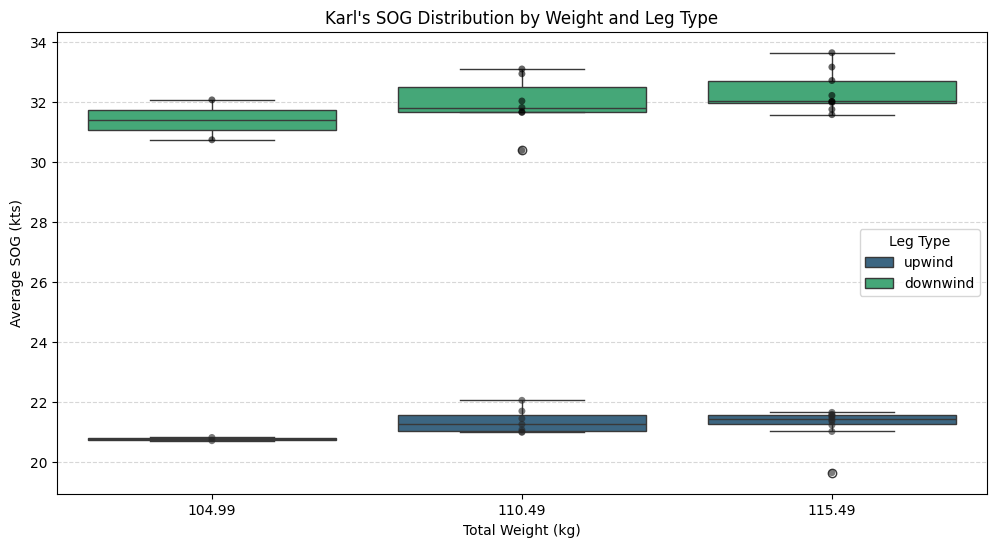

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

print("DESCRIPTIVE STATISTICS (SOG)")
stats_summary = df_intervals.groupby(['leg_type', 'total_weight'])['avg_SOG'].agg(['mean', 'std', 'count']).reset_index()
stats_summary.columns = ['Leg Type', 'Weight (kg)', 'Mean (kts)', 'Std Dev', 'Nb Runs']
print(stats_summary.to_string(index=False))

plt.figure(figsize=(12, 6))

sns.boxplot(x='total_weight', y='avg_SOG', hue='leg_type', 
            data=df_intervals, palette='viridis', dodge=False)

sns.stripplot(x='total_weight', y='avg_SOG', hue='leg_type', 
              jitter=False, data=df_intervals, dodge=False, 
              color='black', alpha=0.6, legend=False)

plt.title("Karl's SOG Distribution by Weight and Leg Type")
plt.xlabel('Total Weight (kg)')
plt.ylabel('Average SOG (kts)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Leg Type')
plt.show()

In [4]:
import scipy.stats as stats

# --- 1. GLOBAL ANOVA (Combined Days & Combined Legs) ---
print("=== GLOBAL ANOVA (Combined Days & Legs) ===")
all_weights = df_intervals['total_weight'].unique()
global_groups = [df_intervals[df_intervals['total_weight'] == w]['avg_SOG'] for w in all_weights]
total_runs_gen = len(df_intervals)

f_stat_gen, p_val_gen = stats.f_oneway(*global_groups)
status = "SIGNIFICANT" if p_val_gen < 0.05 else "NOT SIGNIFICANT"
print(f"Global ANOVA| Total Runs: {total_runs_gen:2} | F: {f_stat_gen:.4f} | p: {p_val_gen:.5f} | {status}")

print("-" * 40 + "\n")



# --- 2. GLOBAL ANOVA BY LEG TYPE (Combined Days) ---
print("=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===")
for leg in df_intervals['leg_type'].unique():
    subset_leg = df_intervals[df_intervals['leg_type'] == leg]
    weights_leg = subset_leg['total_weight'].unique()
    num_runs_leg = len(subset_leg)
    
    if len(weights_leg) > 1:
        groups_leg = [subset_leg[subset_leg['total_weight'] == w]['avg_SOG'] for w in weights_leg]
        f_l, p_l = stats.f_oneway(*groups_leg)
        status = "SIGNIFICANT" if p_l < 0.05 else "NOT SIGNIFICANT"
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | F: {f_l:.4f} | p: {p_l:.5f} | {status}")
    else:
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | Insufficient weight variations")
print("-" * 40 + "\n")


# --- 3. ANOVA BY DAY AND LEG TYPE ---
unique_days = df_intervals['day'].unique()

for day in unique_days:
    print(f"=== ANALYSIS FOR DAY: {day} ===")
    df_day = df_intervals[df_intervals['day'] == day]
    total_runs_day = len(df_day)
    
    # Global for the specific day
    weights_day = df_day['total_weight'].unique()
    if len(weights_day) > 1:
        groups_day = [df_day[df_day['total_weight'] == w]['avg_SOG'] for w in weights_day]
        f_d, p_d = stats.f_oneway(*groups_day)
        status = "SIGNIFICANT" if p_d < 0.05 else "NOT SIGNIFICANT"
        print(f"  Day Global ANOVA | Runs: {total_runs_day:2} | F: {f_d:.4f} | p: {p_d:.5f} | {status}")
    # Detail by leg type for the specific day
    for leg in df_day['leg_type'].unique():
        subset_day_leg = df_day[df_day['leg_type'] == leg]
        weights_day_leg = subset_day_leg['total_weight'].unique()
        num_runs_day_leg = len(subset_day_leg)
        
        if len(weights_day_leg) > 1:
            groups_day_leg = [subset_day_leg[subset_day_leg['total_weight'] == w]['avg_SOG'] for w in weights_day_leg]
            f_dl, p_dl = stats.f_oneway(*groups_day_leg)
            status = "SIGNIFICANT" if p_dl < 0.05 else "NOT SIGNIFICANT"
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | F: {f_dl:.4f} | p: {p_dl:.5f} | {status}")
        else:
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | Insufficient weight variations")
            
    print("-" * 40 + "\n")

=== GLOBAL ANOVA (Combined Days & Legs) ===
Global ANOVA| Total Runs: 37 | F: 0.0155 | p: 0.98462 | NOT SIGNIFICANT
----------------------------------------

=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===
Leg: UPWIND    | Total Runs: 19 | F: 1.0713 | p: 0.36589 | NOT SIGNIFICANT
Leg: DOWNWIND  | Total Runs: 18 | F: 1.2988 | p: 0.30184 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 26_11_2025 ===
  Day Global ANOVA | Runs: 19 | F: 0.0021 | p: 0.96391 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs: 10 | F: 0.3017 | p: 0.59781 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  9 | F: 1.9088 | p: 0.20958 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 27_11_2025 ===
  Day Global ANOVA | Runs: 18 | F: 0.0102 | p: 0.98989 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs:  9 | F: 0.1592 | p: 0.85628 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  9 | F: 1.0407 | p: 0.40927 | NOT SIGNIFICANT
----------------------------------------



In [5]:
from statsmodels.formula.api import ols

# --- 1. GLOBAL OLS REGRESSION (Combined Days) ---
print("GLOBAL OLS REGRESSION (All Days)")
for leg in df_intervals['leg_type'].unique():
    subset = df_intervals[df_intervals['leg_type'] == leg]
    num_runs = len(subset)
    
    # Model: Speed depends on Weight and Wind
    model = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset).fit()
    
    print(f"\n LEG TYPE: {leg.upper()} | Sample Size (N): {num_runs}")
    print(f"R-squared: {model.rsquared:.3f}")
    print(model.summary().tables[1])
    
    coef_weight = model.params['total_weight']
    p_weight = model.pvalues['total_weight']

    status = "SIGNIFICANT" if p_weight < 0.05 else "NOT SIGNIFICANT"
    print(f"Impact of 1kg: {coef_weight:.4f} kts | Status: {status}")
    print("-" * 60 + "\n")


# --- 2. OLS REGRESSION BY DAY ---
unique_days = df_intervals['day'].unique()

for day in unique_days:
    print(f"\n\n\n\n ANALYSIS FOR DAY: {day}")
    df_day = df_intervals[df_intervals['day'] == day]
    for leg in df_day['leg_type'].unique():
        subset_day = df_day[df_day['leg_type'] == leg]
        num_runs_day = len(subset_day)
        # We need at least 3 runs to solve for intercept + weight + TWS
        if num_runs_day > 2:
            model_day = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset_day).fit()
            
            print(f"\n LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print(f"R-squared: {model_day.rsquared:.3f}")
            print(model_day.summary().tables[1])
            
            cw = model_day.params['total_weight']
            pw = model_day.pvalues['total_weight']
            
            status = "SIGNIFICANT" if pw < 0.05 else "NOT SIGNIFICANT"
            print(f"Impact of 1kg: {cw:.4f} kts | Status: {status}")
        else:
            print(f"LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print("Not enough data points for regression on this specific day.")
            
        print("-" * 30)
    print("\n")

GLOBAL OLS REGRESSION (All Days)

 LEG TYPE: UPWIND | Sample Size (N): 19
R-squared: 0.087
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.2565      4.147      4.643      0.000      10.417      28.096
total_weight     0.0274      0.036      0.772      0.452      -0.048       0.103
avg_TWS         -0.0272      0.084     -0.322      0.752      -0.207       0.153
avg_TWA         -0.0202      0.021     -0.973      0.346      -0.065       0.024
Impact of 1kg: 0.0274 kts | Status: NOT SIGNIFICANT
------------------------------------------------------------


 LEG TYPE: DOWNWIND | Sample Size (N): 18
R-squared: 0.286
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       21.4021      8.880      2.410      0.030       2.357      40.448
total_

c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
 

# Same analysis, but deleting manually runs where Karl fell

In [6]:
runs_to_remove = [
    "26_11_2025_Run3",
    "26_11_2025_Run4",
    "26_11_2025_Run10",
    "26_11_2025_Run5",
    "27_11_2025_Run7",
]

df_filtered = df_intervals.copy()
df_filtered = df_filtered[~df_filtered["run"].isin(runs_to_remove)].reset_index(drop=True)

DESCRIPTIVE STATISTICS (SOG)
Leg Type  Weight (kg)  Mean (kts)  Std Dev  Nb Runs
downwind       104.99   31.395283 0.940095        2
downwind       110.49   32.191253 0.650845        6
downwind       115.49   32.373171 0.724295        8
  upwind       104.99   20.757998 0.076105        2
  upwind       110.49   21.239199 0.282816        6
  upwind       115.49   21.419783 0.201170        9


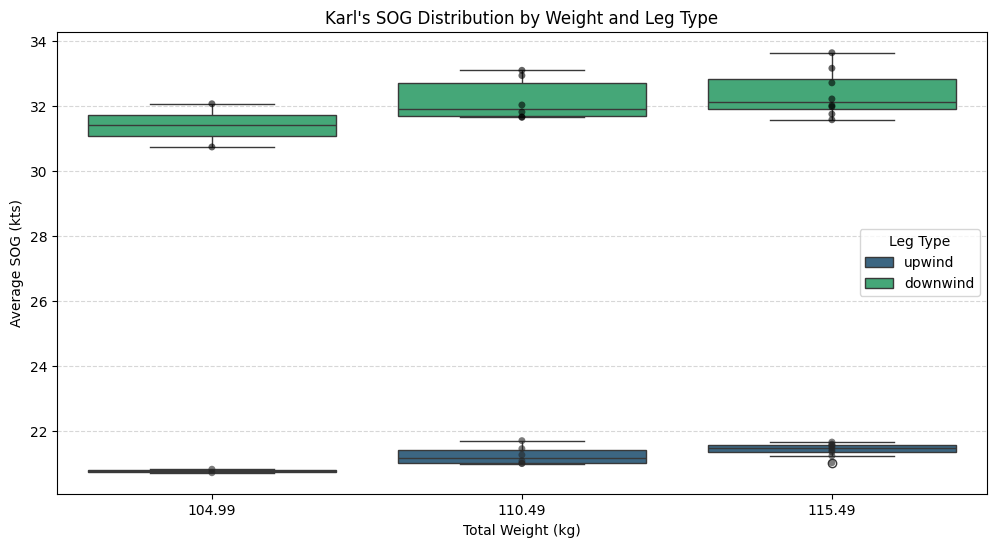

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

print("DESCRIPTIVE STATISTICS (SOG)")
stats_summary = df_filtered.groupby(['leg_type', 'total_weight'])['avg_SOG'].agg(['mean', 'std', 'count']).reset_index()
stats_summary.columns = ['Leg Type', 'Weight (kg)', 'Mean (kts)', 'Std Dev', 'Nb Runs']
print(stats_summary.to_string(index=False))

plt.figure(figsize=(12, 6))

sns.boxplot(x='total_weight', y='avg_SOG', hue='leg_type', 
            data=df_filtered, palette='viridis', dodge=False)

sns.stripplot(x='total_weight', y='avg_SOG', hue='leg_type', 
              jitter=False, data=df_filtered, dodge=False, 
              color='black', alpha=0.6, legend=False)

plt.title("Karl's SOG Distribution by Weight and Leg Type")
plt.xlabel('Total Weight (kg)')
plt.ylabel('Average SOG (kts)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Leg Type')
plt.show()

In [8]:
import scipy.stats as stats

# --- 1. GLOBAL ANOVA (Combined Days & Combined Legs) ---
print("=== GLOBAL ANOVA (Combined Days & Legs) ===")
all_weights = df_filtered['total_weight'].unique()
global_groups = [df_filtered[df_filtered['total_weight'] == w]['avg_SOG'] for w in all_weights]
total_runs_gen = len(df_filtered)

f_stat_gen, p_val_gen = stats.f_oneway(*global_groups)
status = "SIGNIFICANT" if p_val_gen < 0.05 else "NOT SIGNIFICANT"
print(f"Global ANOVA| Total Runs: {total_runs_gen:2} | F: {f_stat_gen:.4f} | p: {p_val_gen:.5f} | {status}")

print("-" * 40 + "\n")



# --- 2. GLOBAL ANOVA BY LEG TYPE (Combined Days) ---
print("=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===")
for leg in df_filtered['leg_type'].unique():
    subset_leg = df_filtered[df_filtered['leg_type'] == leg]
    weights_leg = subset_leg['total_weight'].unique()
    num_runs_leg = len(subset_leg)
    
    if len(weights_leg) > 1:
        groups_leg = [subset_leg[subset_leg['total_weight'] == w]['avg_SOG'] for w in weights_leg]
        f_l, p_l = stats.f_oneway(*groups_leg)
        status = "SIGNIFICANT" if p_l < 0.05 else "NOT SIGNIFICANT"
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | F: {f_l:.4f} | p: {p_l:.5f} | {status}")
    else:
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | Insufficient weight variations")
print("-" * 40 + "\n")


# --- 3. ANOVA BY DAY AND LEG TYPE ---
unique_days = df_filtered['day'].unique()

for day in unique_days:
    print(f"=== ANALYSIS FOR DAY: {day} ===")
    df_day = df_filtered[df_filtered['day'] == day]
    total_runs_day = len(df_day)
    
    # Global for the specific day
    weights_day = df_day['total_weight'].unique()
    if len(weights_day) > 1:
        groups_day = [df_day[df_day['total_weight'] == w]['avg_SOG'] for w in weights_day]
        f_d, p_d = stats.f_oneway(*groups_day)
        status = "SIGNIFICANT" if p_d < 0.05 else "NOT SIGNIFICANT"
        print(f"  Day Global ANOVA | Runs: {total_runs_day:2} | F: {f_d:.4f} | p: {p_d:.5f} | {status}")
    # Detail by leg type for the specific day
    for leg in df_day['leg_type'].unique():
        subset_day_leg = df_day[df_day['leg_type'] == leg]
        weights_day_leg = subset_day_leg['total_weight'].unique()
        num_runs_day_leg = len(subset_day_leg)
        
        if len(weights_day_leg) > 1:
            groups_day_leg = [subset_day_leg[subset_day_leg['total_weight'] == w]['avg_SOG'] for w in weights_day_leg]
            f_dl, p_dl = stats.f_oneway(*groups_day_leg)
            status = "SIGNIFICANT" if p_dl < 0.05 else "NOT SIGNIFICANT"
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | F: {f_dl:.4f} | p: {p_dl:.5f} | {status}")
        else:
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | Insufficient weight variations")
            
    print("-" * 40 + "\n")

=== GLOBAL ANOVA (Combined Days & Legs) ===
Global ANOVA| Total Runs: 33 | F: 0.0186 | p: 0.98158 | NOT SIGNIFICANT
----------------------------------------

=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===
Leg: UPWIND    | Total Runs: 17 | F: 7.0123 | p: 0.00776 | SIGNIFICANT
Leg: DOWNWIND  | Total Runs: 16 | F: 1.4908 | p: 0.26127 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 26_11_2025 ===
  Day Global ANOVA | Runs: 17 | F: 0.0081 | p: 0.92948 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs:  9 | F: 0.1740 | p: 0.68905 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  8 | F: 0.5253 | p: 0.49588 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 27_11_2025 ===
  Day Global ANOVA | Runs: 16 | F: 0.0133 | p: 0.98684 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs:  8 | F: 4.4534 | p: 0.07751 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  8 | F: 0.8584 | p: 0.47809 | NOT SIGNIFICANT
----------------------------------------



In [9]:
from statsmodels.formula.api import ols

# --- 1. GLOBAL OLS REGRESSION (Combined Days) ---
print("GLOBAL OLS REGRESSION (All Days)")
for leg in df_filtered['leg_type'].unique():
    subset = df_filtered[df_filtered['leg_type'] == leg]
    num_runs = len(subset)
    
    # Model: Speed depends on Weight and Wind
    model = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset).fit()
    
    print(f"\n LEG TYPE: {leg.upper()} | Sample Size (N): {num_runs}")
    print(f"R-squared: {model.rsquared:.3f}")
    print(model.summary().tables[1])
    
    coef_weight = model.params['total_weight']
    p_weight = model.pvalues['total_weight']

    status = "SIGNIFICANT" if p_weight < 0.05 else "NOT SIGNIFICANT"
    print(f"Impact of 1kg: {coef_weight:.4f} kts | Status: {status}")
    print("-" * 60 + "\n")


# --- 2. OLS REGRESSION BY DAY ---
unique_days = df_filtered['day'].unique()

for day in unique_days:
    print(f"\n\n\n\n ANALYSIS FOR DAY: {day}")
    df_day = df_filtered[df_filtered['day'] == day]
    for leg in df_day['leg_type'].unique():
        subset_day = df_day[df_day['leg_type'] == leg]
        num_runs_day = len(subset_day)
        # We need at least 3 runs to solve for intercept + weight + TWS
        if num_runs_day > 2:
            model_day = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset_day).fit()
            
            print(f"\n LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print(f"R-squared: {model_day.rsquared:.3f}")
            print(model_day.summary().tables[1])
            
            cw = model_day.params['total_weight']
            pw = model_day.pvalues['total_weight']
            
            status = "SIGNIFICANT" if pw < 0.05 else "NOT SIGNIFICANT"
            print(f"Impact of 1kg: {cw:.4f} kts | Status: {status}")
        else:
            print(f"LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print("Not enough data points for regression on this specific day.")
            
        print("-" * 30)
    print("\n")

GLOBAL OLS REGRESSION (All Days)

 LEG TYPE: UPWIND | Sample Size (N): 17
R-squared: 0.532
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       15.8761      1.876      8.463      0.000      11.823      19.929
total_weight     0.0573      0.016      3.665      0.003       0.024       0.091
avg_TWS         -0.0384      0.042     -0.905      0.382      -0.130       0.053
avg_TWA         -0.0132      0.010     -1.383      0.190      -0.034       0.007
Impact of 1kg: 0.0573 kts | Status: SIGNIFICANT
------------------------------------------------------------


 LEG TYPE: DOWNWIND | Sample Size (N): 16
R-squared: 0.557
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       28.5508      6.722      4.248      0.001      13.905      43.196
total_weig

c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  